In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Online retail Dataset.csv")

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

       InvoiceDate  UnitPrice  CustomerID         Country  
0  01/12/2010 8:26       2.55     17850.0  United Kingdom  
1  01/12/2010 8:26       3.39     17850.0  United Kingdom  
2  01/12/2010 8:26       2.75     17850.0  United Kingdom  
3  01/12/2010 8:26       3.39     17850.0  United Kingdom  
4  01/12/2010 8:26       3.39     17850.0  United Kingdom  


In [3]:
print(df.shape)


(542014, 8)


In [4]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [5]:
#checking missing values

print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
#data cleaning
df = df.dropna(subset=["CustomerID", "Description"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["CustomerID"] = df["CustomerID"].astype(int)

print(df.shape)
print(df.head())

(397988, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-01-12 08:26:00       2.55       17850  United Kingdom  
1 2010-01-12 08:26:00       3.39       17850  United Kingdom  
2 2010-01-12 08:26:00       2.75       17850  United Kingdom  
3 2010-01-12 08:26:00       3.39       17850  United Kingdom  
4 2010-01-12 08:26:00       3.39       17850  United Kingdom  


In [11]:
#now we creating revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
print(df[["Quantity", "UnitPrice", "Revenue"]].head())

   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [13]:
#creating a RFM table

import datetime as dt
snapshot_date = df["InvoiceDate"].max()+ dt.timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.head())
print(rfm.shape)

            Recency  Frequency  Monetary
CustomerID                              
12346           NaN          1  77183.60
12347          96.0          7   4310.00
12348         221.0          4   1797.24
12349           NaN          1   1757.55
12350         312.0          1    334.40
(4338, 3)


In [14]:
#create a churn label
rfm["Churn"] = rfm["Recency"].apply(lambda x: 1 if x > 90 else 0)

print(rfm.head())
print(rfm["Churn"].value_counts())

            Recency  Frequency  Monetary  Churn
CustomerID                                     
12346           NaN          1  77183.60      0
12347          96.0          7   4310.00      1
12348         221.0          4   1797.24      1
12349           NaN          1   1757.55      0
12350         312.0          1    334.40      1
Churn
0    2455
1    1883
Name: count, dtype: int64


In [15]:
#Standardizing data for clustering

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

print(rfm_scaled[:5])

[[        nan -0.4250965   8.3544143 ]
 [-0.42384826  0.3544168   0.25031873]
 [ 0.46827774 -0.03533985 -0.02911919]
 [        nan -0.4250965  -0.03353302]
 [ 1.11774546 -0.4250965  -0.19179806]]


In [16]:
#Apply KMeans clustering

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())
print(rfm["Cluster"].value_counts())

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [17]:
print(rfm.isnull().sum())
print(rfm.head())

Recency      1341
Frequency       0
Monetary        0
Churn           0
dtype: int64
            Recency  Frequency  Monetary  Churn
CustomerID                                     
12346           NaN          1  77183.60      0
12347          96.0          7   4310.00      1
12348         221.0          4   1797.24      1
12349           NaN          1   1757.55      0
12350         312.0          1    334.40      1


In [18]:
print(df["InvoiceDate"].isnull().sum())
print(df[df["InvoiceDate"].isnull()].head())

229253
      InvoiceNo StockCode                        Description  Quantity  \
26837    538521     21754           HOME BUILDING BLOCK WORD         3   
26838    538521     21755           LOVE BUILDING BLOCK WORD         3   
26839    538521     22072  RED RETROSPOT TEA CUP AND SAUCER          8   
26840    538521     22846         BREAD BIN DINER STYLE RED          1   
26841    538521     22849         BREAD BIN DINER STYLE MINT         1   

      InvoiceDate  UnitPrice  CustomerID         Country  revenue  Revenue  
26837         NaT       5.95       14180  United Kingdom    17.85    17.85  
26838         NaT       5.95       14180  United Kingdom    17.85    17.85  
26839         NaT       3.75       14180  United Kingdom    30.00    30.00  
26840         NaT      16.95       14180  United Kingdom    16.95    16.95  
26841         NaT      16.95       14180  United Kingdom    16.95    16.95  


In [19]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
print(df["InvoiceDate"].isnull().sum())

229253


In [20]:
import pandas as pd

df = pd.read_csv("Online Retail Dataset.csv", encoding="ISO-8859-1")

print(df["InvoiceDate"].head())

0    01/12/2010 8:26
1    01/12/2010 8:26
2    01/12/2010 8:26
3    01/12/2010 8:26
4    01/12/2010 8:26
Name: InvoiceDate, dtype: object


In [21]:
df = df.dropna(subset=["CustomerID", "Description"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print(df.shape)

(397988, 8)


In [22]:
df = df.dropna(subset=["CustomerID", "Description"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print(df.shape)

(397988, 8)


In [23]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

print(df["InvoiceDate"].isnull().sum())
print(df["InvoiceDate"].head())

229253
0   2010-01-12 08:26:00
1   2010-01-12 08:26:00
2   2010-01-12 08:26:00
3   2010-01-12 08:26:00
4   2010-01-12 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]


In [24]:
df = df.dropna(subset=["InvoiceDate"])
print(df["InvoiceDate"].isnull().sum())
print(df.shape)

0
(168735, 8)


In [25]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(df[["Quantity", "UnitPrice", "Revenue"]].head())

   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [26]:
#get some error before so we rebuild this itmem again
import datetime as dt

snapshot_date = df["InvoiceDate"].max() + dt.timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.isnull().sum())
print(rfm.head())

Recency      0
Frequency    0
Monetary     0
dtype: int64
            Recency  Frequency  Monetary
CustomerID                              
12347.0          96          5   2540.29
12348.0         221          1    367.00
12350.0         312          1    334.40
12352.0         275          3   1296.38
12355.0          97          1    459.40


In [27]:
#Standardize and KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# scale features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())
print(rfm["Cluster"].value_counts())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12347.0          96          5   2540.29        0
12348.0         221          1    367.00        1
12350.0         312          1    334.40        1
12352.0         275          3   1296.38        1
12355.0          97          1    459.40        0
Cluster
0    2083
1     862
2      49
3       3
Name: count, dtype: int64


In [28]:
#Cluster summary
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
print(cluster_summary)

            Recency  Frequency       Monetary
Cluster                                      
0         86.417187   2.734518    1051.199818
1        328.671694   1.279582     466.780209
2         44.714286  22.530612   18619.159796
3         61.000000  19.333333  130680.010000


INTERPRETATION 

Cluster 2 - VIP customers (high spend + frequent)

Cluster 1 - Lost customers (high recency, low frequency)

Cluster 0 - Loyal customers

Cluster 3 - Medium customers

In [29]:
#for better churn model

In [33]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# create churn
rfm["Churn"] = rfm["Recency"].apply(lambda x: 1 if x > 90 else 0)

X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))
print(classification_report(y_test, pred))

Accuracy: 1.0
ROC AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       207
           1       1.00      1.00      1.00       393

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



C:\Users\neela\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:52:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [32]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.7/101.7 MB 44.7 MB/s eta 0:00:03
   ------- -------------------------------- 20.2/101.7 MB 70.5 MB/s eta 0:00:02
   --------------- ------------------------ 40.6/101.7 MB 83.3 MB/s eta 0:00:01
   ------------------------ --------------- 61.6/101.7 MB 89.2 MB/s eta 0:00:01
   --------------------------------- ------ 84.1/101.7 MB 93.0 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 94.5 MB/s eta 0:00:01
   ---------------------------------------- 101.7/101.7 MB 78.6 MB/s  0:00:01


In [34]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

     Feature  Importance
0    Recency         1.0
1  Frequency         0.0
2   Monetary         0.0


In [35]:
#future revenue prediction
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_reg = rfm[["Recency", "Frequency", "Monetary"]]
y_reg = rfm["Monetary"]   # using current spend as proxy

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train, y_train)

pred_reg = reg_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_reg))
print("R2 Score:", r2_score(y_test, pred_reg))

MAE: 16.875205166666618
R2 Score: 0.998086101112333


In [36]:
#i am adding here some visualization here
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

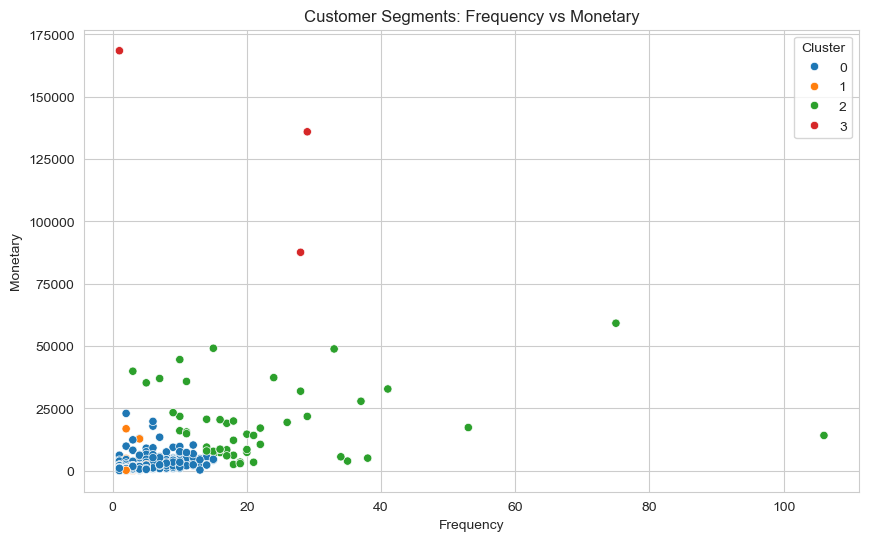

In [37]:
#cluster scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=rfm.reset_index(),
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10"
)
plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

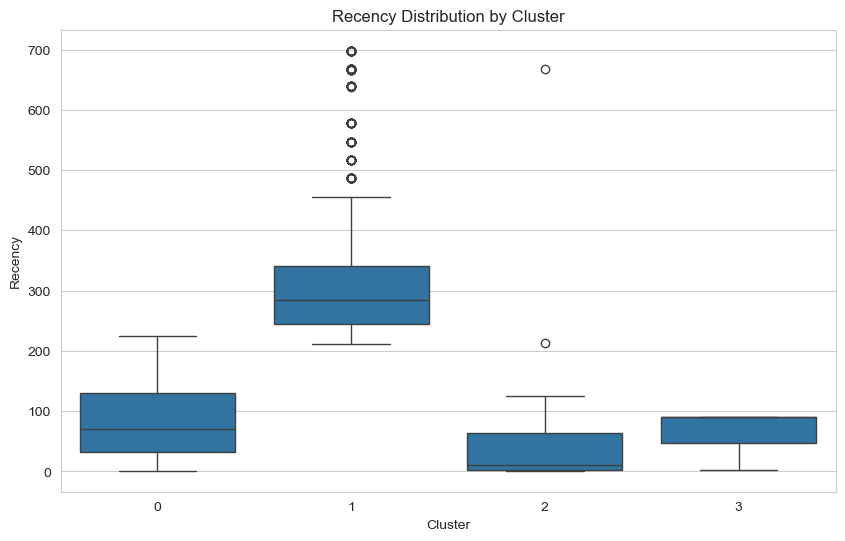

In [38]:
#recency by cluster
plt.figure(figsize=(10,6))
sns.boxplot(data=rfm.reset_index(), x="Cluster", y="Recency")
plt.title("Recency Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Recency")
plt.show()

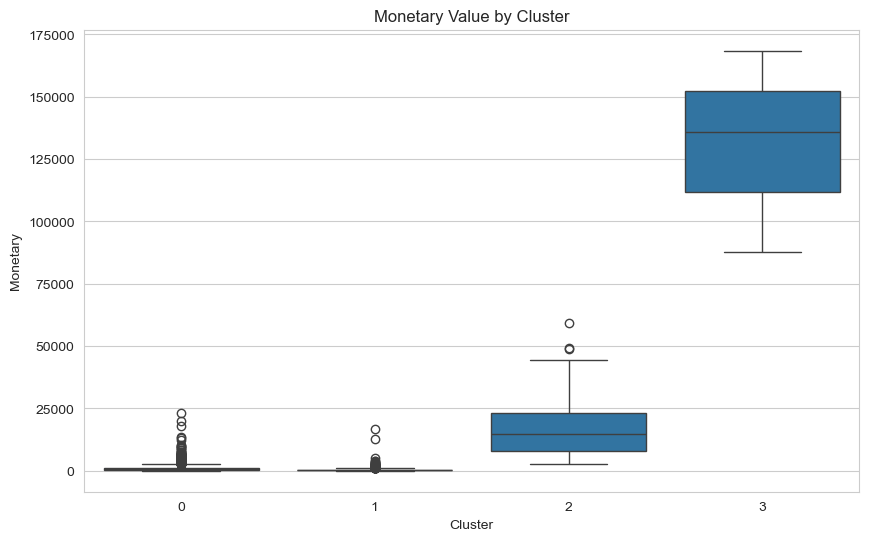

In [40]:
#Monetary by cluster
plt.figure(figsize=(10,6))
sns.boxplot(data=rfm.reset_index(), x="Cluster", y="Monetary")
plt.title("Monetary Value by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Monetary")
plt.show()

In [41]:
rfm.to_csv("final_customer_insights.csv")

In [42]:
rfm.to_csv("final_customer_insights.csv")

In [43]:
importance.to_csv("feature_importance.csv", index=False)

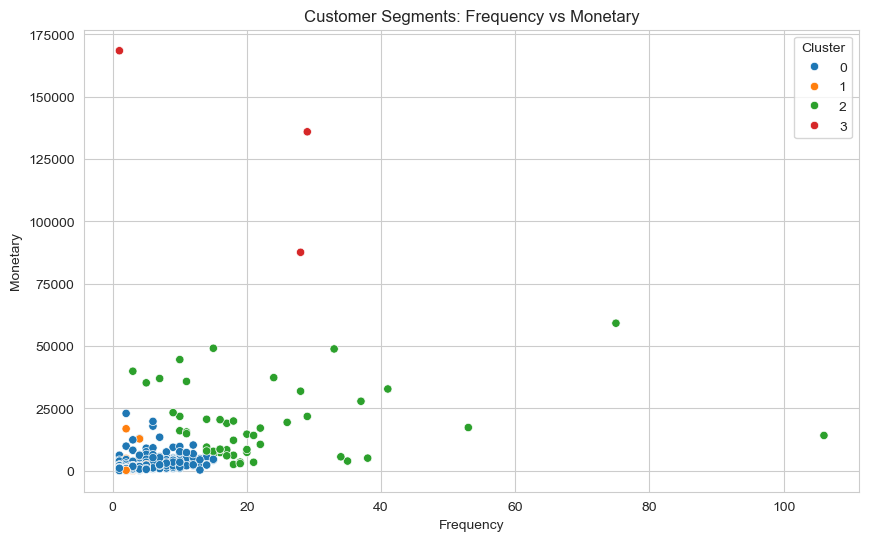

In [44]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm.reset_index(),
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10"
)

plt.title("Customer Segments: Frequency vs Monetary")

plt.savefig("customer_segments_scatter.png", dpi=300, bbox_inches="tight")  # SAVE
plt.show()

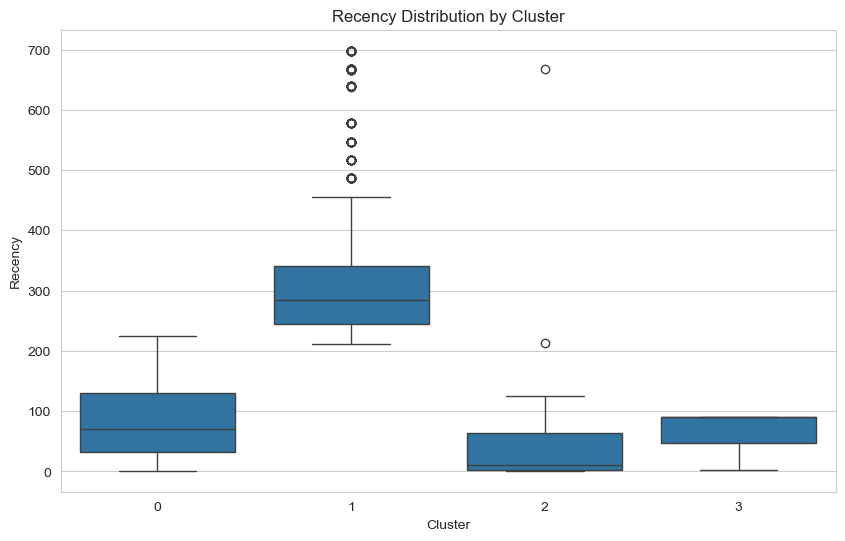

In [46]:
plt.figure(figsize=(10,6))

sns.boxplot(data=rfm.reset_index(), x="Cluster", y="Recency")

plt.title("Recency Distribution by Cluster")

plt.savefig("recency_by_cluster.png", dpi=300, bbox_inches="tight")
plt.show()

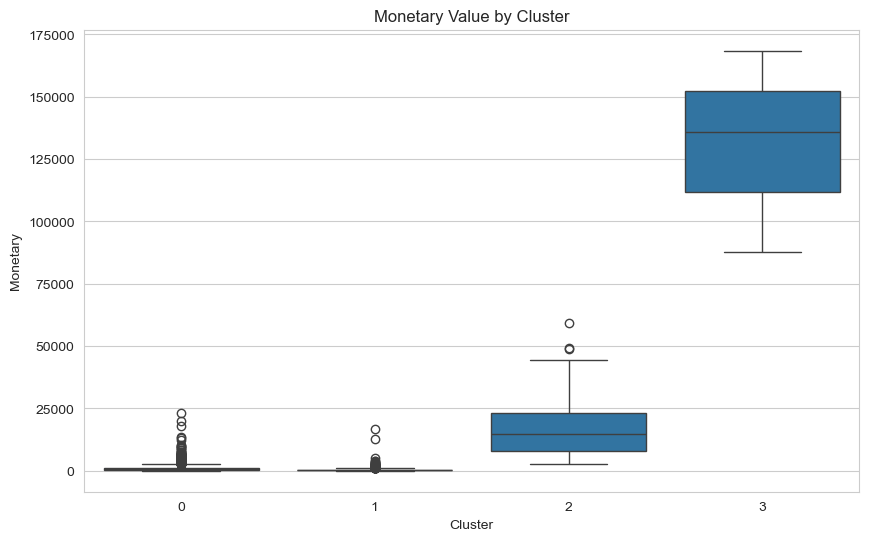

In [47]:
plt.figure(figsize=(10,6))

sns.boxplot(data=rfm.reset_index(), x="Cluster", y="Monetary")

plt.title("Monetary Value by Cluster")

plt.savefig("monetary_by_cluster.png", dpi=300, bbox_inches="tight")
plt.show()